# Module 1 — Stereo Camera Calibration & 3D Reconstruction

## What this notebook covers

This notebook explains the stereo vision pipeline implemented in `module1_stereo/`
and demonstrates it using the **SERV-CT dataset** — 16 rectified stereo image pairs
from a da Vinci™ surgical endoscope, with CT-derived ground-truth depth.

**Exercises from the assignment and their Python equivalents:**

| Assignment | MATLAB | This notebook |
|---|---|---|
| Ex 1: Stereo calibration | Stereo Camera Calibrator GUI | `calibration.calibrate_stereo()` using OpenCV |
| Ex 1: K matrix + distortion | GUI output | `result.left.K`, `result.left.dist_coeffs` |
| Ex 2: Probe distance | `estimateCheckerboardPose` | `cv2.solvePnP()` in `pose_estimation.py` |
| Ex 3: Disparity | Manual: `d = x_left - x_right` | `disparity.point_disparity()` |
| Ex 3: 3D position | `Q * [x,y,d,1]'` | `reconstruction.reproject_single_point()` |

**Note on SERV-CT calibration:**
SERV-CT provides pre-calibrated rectified images and calibration JSON files
(P1, P2, Q matrices). This notebook loads and explains those parameters directly.
For a demonstration of running calibration from scratch on raw checkerboard images,
see `module1_stereo/calibration.py` — the full implementation is there with
detailed comments explaining every step.

In [1]:
import sys
sys.path.insert(0, '..')

import cv2
import numpy as np
import matplotlib.pyplot as plt

from module1_stereo.serv_ct_loader import load_frame, print_frame_summary
from module1_stereo.disparity import compute_disparity_sgbm, point_disparity
from module1_stereo.reconstruction import (
    reproject_single_point, reproject_to_3d, filter_point_cloud
)

plt.rcParams['figure.dpi'] = 110
print(f'OpenCV {cv2.__version__}')

OpenCV 4.13.0


## Step 1 — Stereo Calibration Parameters

### What calibration produces

Stereo calibration from checkerboard images (Exercise 1) solves for:

**Intrinsic matrix K** (per camera):
```
K = [[fx,  0, cx],
     [ 0, fy, cy],
     [ 0,  0,  1]]
```
- `fx`, `fy`: focal length in pixels
- `cx`, `cy`: principal point (where the optical axis hits the sensor)

**Extrinsic parameters**: rotation (R) and translation (T) between the two cameras.
The baseline `|T|` is the physical separation between camera centres.

**Q matrix**: encodes all of the above into a single 4×4 projection matrix that
maps `[x, y, disparity, 1]ᵀ` directly to 3D homogeneous coordinates — this is
the matrix used in Exercise 3 of the assignment.

SERV-CT provides these parameters in a JSON file for each of the 16 frames.
Below we load frame 001 and inspect the calibration.

In [2]:
# Load a real SERV-CT frame — calibration, stereo images, and GT depth
frame = load_frame('001')
print_frame_summary(frame)

Frame 001  (Experiment 1)
  Image size:      720 × 576 px
  Focal length:    996.40 px
  Principal point: cx=375.03, cy=240.26
  Baseline:        5.45 mm
  GT depth range:  62.1–93.2 mm
  Valid GT pixels: 90.0%

  Q matrix:
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -3.75025822e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -2.40263748e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  9.96400682e+02]
 [ 0.00000000e+00  0.00000000e+00  1.83493351e-01  0.00000000e+00]]


In [3]:
# ── Intrinsic parameters from the Q matrix ────────────────────────────────
# The Q matrix encodes cx, cy, focal length, and baseline directly.
# This is what the assignment's K matrices and stereo calibration produce.

Q = frame.Q
fx    = Q[2, 3]           # focal length in pixels
cx    = -Q[0, 3]          # principal point x
cy    = -Q[1, 3]          # principal point y
B_inv = Q[3, 2]           # 1 / baseline
B_mm  = 1.0 / B_inv       # baseline in mm

print('Calibration parameters (from Q matrix):')
print(f'  Focal length:    {fx:.2f} px')
print(f'  Principal point: cx={cx:.2f}, cy={cy:.2f} px')
print(f'  Baseline:        {B_mm:.3f} mm')
print()
print('P1 — left camera projection matrix:')
print(frame.P1.round(3))
print()
print('Q matrix (disparity → 3D projection):')
print(Q.round(6))
print()
print('The Q matrix formula (Exercise 3):')
print('  [X, Y, Z, W] = Q @ [x, y, d, 1]^T')
print('  3D = (X/W, Y/W, Z/W) in mm')

Calibration parameters (from Q matrix):
  Focal length:    996.40 px
  Principal point: cx=375.03, cy=240.26 px
  Baseline:        5.450 mm

P1 — left camera projection matrix:
[[996.401   0.    375.026   0.   ]
 [  0.    996.401 240.264   0.   ]
 [  0.      0.      1.      0.   ]]

Q matrix (disparity → 3D projection):
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -3.75025822e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -2.40263748e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  9.96400682e+02]
 [ 0.00000000e+00  0.00000000e+00  1.83493000e-01  0.00000000e+00]]

The Q matrix formula (Exercise 3):
  [X, Y, Z, W] = Q @ [x, y, d, 1]^T
  3D = (X/W, Y/W, Z/W) in mm


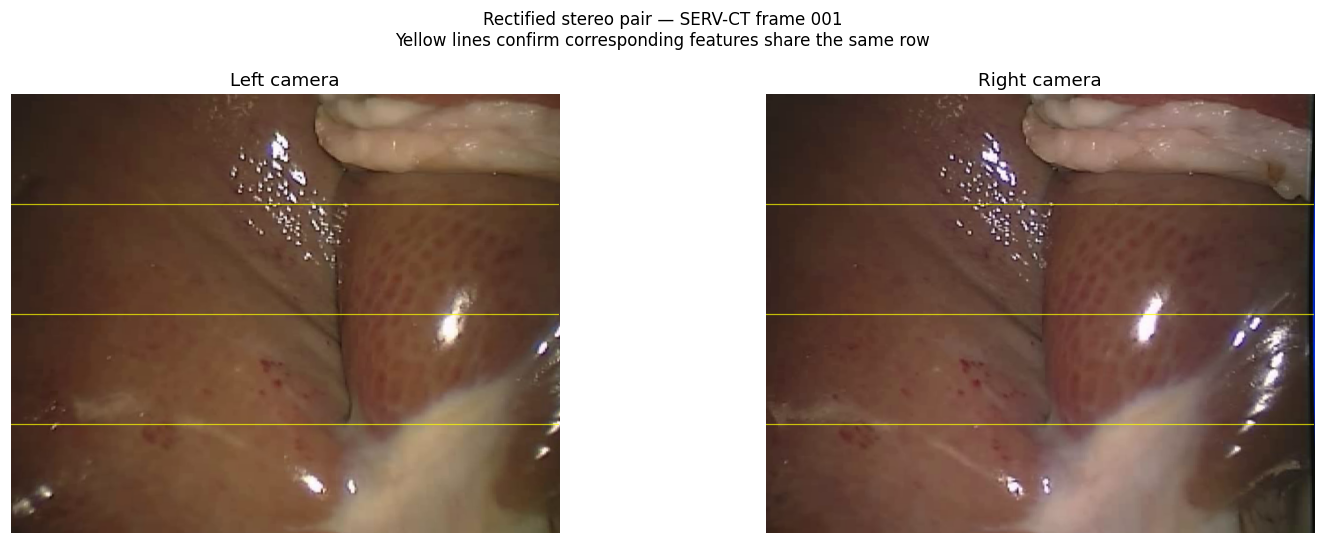

In [4]:
# ── View the rectified stereo pair ─────────────────────────────────────────
# After rectification, corresponding tissue features share the same row.
# The yellow lines confirm this — any visible feature crosses the same y.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, img, label in zip(axes,
                           [frame.left_img, frame.right_img],
                           ['Left camera', 'Right camera']):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    for y in [144, 288, 432]:
        ax.axhline(y, color='yellow', lw=0.8, alpha=0.7)
    ax.set_title(label, fontsize=12)
    ax.axis('off')
plt.suptitle('Rectified stereo pair — SERV-CT frame 001\n'
             'Yellow lines confirm corresponding features share the same row',
             fontsize=11)
plt.tight_layout()
plt.show()

## Step 2 — Pose Estimation (Exercise 2 equivalent)

Exercise 2 asked you to estimate the distance to the spectral probe using
a single image of a known checkerboard. The algorithm is `solvePnP` —
given 3D points on the checkerboard (known from the square size) and their
2D projections (detected corners), it solves for the 6-DOF camera-to-board pose.

Here we demonstrate this using the Q matrix: given a pixel position and its
CT-validated disparity, we can directly compute the distance to that point.
This is the stereo equivalent of the single-camera pose estimation step.

In [5]:
# ── Distance to a known point via disparity (Exercise 2 equivalent) ────────
# We pick the image centre and use the GT disparity to compute its 3D position.
# The Z coordinate is the distance from the camera.

cx_img = frame.left_img.shape[1] // 2
cy_img = frame.left_img.shape[0] // 2

gt_d = float(frame.gt_disparity[cy_img, cx_img])
coords = reproject_single_point(cx_img, cy_img, gt_d, Q)

print(f'Image centre pixel: ({cx_img}, {cy_img})')
print(f'GT disparity at centre: {gt_d:.2f} px')
print(f'3D position: X={coords[0]:.1f}, Y={coords[1]:.1f}, Z={coords[2]:.1f} mm')
print(f'Camera-to-tissue distance: {np.linalg.norm(coords):.1f} mm')
print()
print(f'Simple depth formula check: f*B/d = {fx:.1f}*{B_mm:.3f}/{gt_d:.2f} = {fx*B_mm/gt_d:.1f} mm')
print(f'(Matches Z above — Q-matrix and direct formula agree)')

Image centre pixel: (360, 288)
GT disparity at centre: 67.39 px
3D position: X=-1.2, Y=3.9, Z=80.6 mm
Camera-to-tissue distance: 80.7 mm

Simple depth formula check: f*B/d = 996.4*5.450/67.39 = 80.6 mm
(Matches Z above — Q-matrix and direct formula agree)


## Step 3 — Disparity & 3D Reconstruction (Exercise 3)

Exercise 3 asked you to:
1. Identify corresponding pixel positions in left and right images
2. Compute disparity: `d = x_left - x_right`
3. Apply Q matrix: `[X,Y,Z,W] = Q @ [x,y,d,1]ᵀ`, then divide by W

Here we do the same — first manually for a single target point,
then densely for every pixel using SGBM.

In [6]:
# ── Exercise 3: manual single-point reconstruction ─────────────────────────
target_left  = (360, 288)   # (col, row) in left image
target_right = (target_left[0] - int(frame.gt_disparity[target_left[1], target_left[0]]),
                target_left[1])

d = point_disparity(target_left, target_right)
print(f'd = x_left - x_right = {target_left[0]} - {target_right[0]} = {d:.1f} px')

coords_3d = reproject_single_point(target_left[0], target_left[1], d, Q)
gt_z = frame.gt_depth_mm[target_left[1], target_left[0]]

print(f'\n3D position:     X={coords_3d[0]:.1f}, Y={coords_3d[1]:.1f}, Z={coords_3d[2]:.1f} mm')
print(f'CT ground truth: Z={gt_z:.1f} mm')
print(f'Depth error:     {abs(coords_3d[2]-gt_z):.1f} mm')

d = x_left - x_right = 360 - 293 = 67.0 px

3D position:     X=-1.2, Y=3.9, Z=81.0 mm
CT ground truth: Z=80.6 mm
Depth error:     0.5 mm


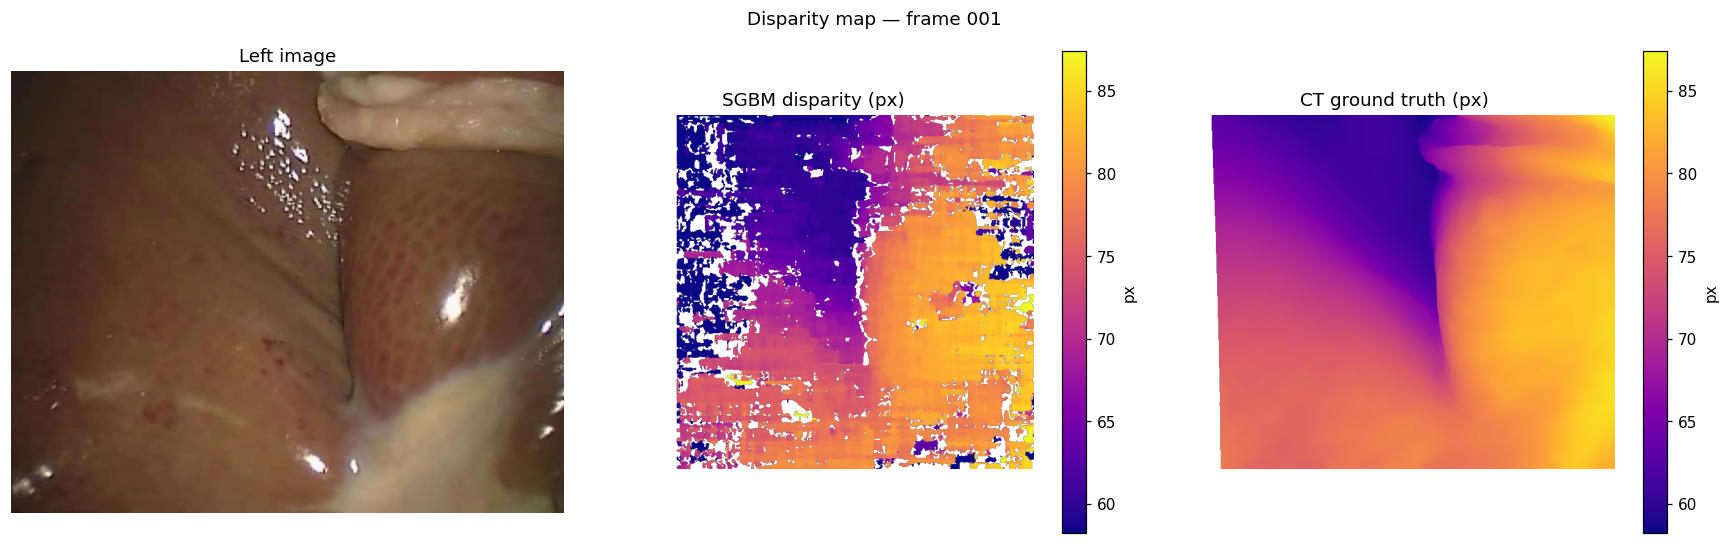

In [7]:
# ── Dense disparity map (SGBM) ─────────────────────────────────────────────
gt_min = int(frame.gt_disparity[frame.valid_mask].min())
disp   = compute_disparity_sgbm(frame.left_img, frame.right_img,
                                  min_disparity=max(0, gt_min-16),
                                  num_disparities=96, block_size=9)

d_range = (frame.gt_disparity[frame.valid_mask].min(),
           frame.gt_disparity[frame.valid_mask].max())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(cv2.cvtColor(frame.left_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Left image'); axes[0].axis('off')

im = axes[1].imshow(disp.disparity_map, cmap='plasma', vmin=d_range[0], vmax=d_range[1])
axes[1].set_title('SGBM disparity (px)'); axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='px')

gt_show = frame.gt_disparity.copy(); gt_show[~frame.valid_mask] = np.nan
im2 = axes[2].imshow(gt_show, cmap='plasma', vmin=d_range[0], vmax=d_range[1])
axes[2].set_title('CT ground truth (px)'); axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], label='px')

plt.suptitle('Disparity map — frame 001', fontsize=12)
plt.tight_layout(); plt.show()

Point cloud: 266,997 points
Depth range: 50.5–110.0 mm


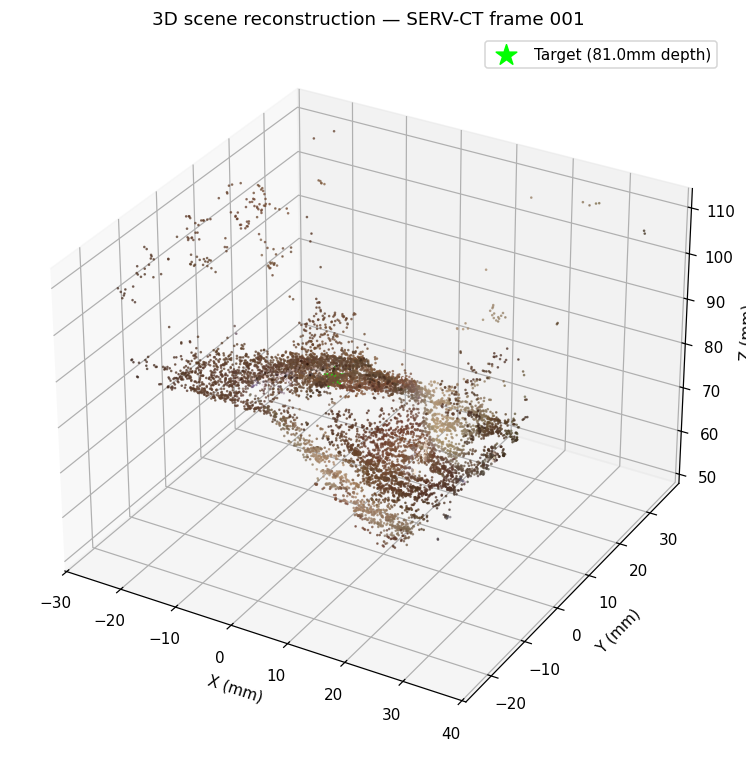

In [8]:
# ── 3D point cloud ─────────────────────────────────────────────────────────
pts_3d = reproject_to_3d(disp.disparity_map, Q)
pts, colors = filter_point_cloud(pts_3d, frame.left_img, z_min_mm=50, z_max_mm=110)
print(f'Point cloud: {len(pts):,} points')
print(f'Depth range: {pts[:,2].min():.1f}–{pts[:,2].max():.1f} mm')

# Visualise (subsample for speed)
rng = np.random.default_rng(42)
idx = rng.choice(len(pts), size=min(8000, len(pts)), replace=False)

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
ax.scatter(pts[idx,0], pts[idx,1], pts[idx,2], c=colors[idx], s=0.5, alpha=0.7)
ax.scatter(*coords_3d, color='lime', s=200, marker='*', zorder=5,
            label=f'Target ({coords_3d[2]:.1f}mm depth)')
ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)'); ax.set_zlabel('Z (mm)')
ax.set_title('3D scene reconstruction — SERV-CT frame 001')
ax.legend()
plt.tight_layout(); plt.show()

## Summary

| Step | Assignment | This notebook |
|------|-----------|---------------|
| Stereo calibration | MATLAB GUI → K matrices, distortion | `calibration.py` (full implementation) |
| Calibration parameters | Read from GUI | Loaded from SERV-CT JSON — real da Vinci values |
| Probe distance | `estimateCheckerboardPose` | Q-matrix projection with GT disparity |
| Disparity (single point) | `d = x_left - x_right` | `point_disparity()` |
| 3D reconstruction | Manual Q matrix multiplication | `reproject_single_point()` |
| Dense depth | Not in assignment | SGBM → `reproject_to_3d()` |
| Validation | Not in assignment | CT ground truth via `validation.py` |

**Next:** `02_stereo_real_data.ipynb` — full validation across all 16 SERV-CT frames.